Loading the CSV

In [161]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dir_path = "../data"
file_name = "prepared_public_emdat_2026.csv"
file_path = os.path.join(dir_path, file_name)
data = pd.read_csv(file_path)

In [162]:
most_important_cols = ['Total Impacted', "Total Damage ('000 US$)", 'Number of Days', 'Fatality Rate', 'Start Year']

In [163]:
def show_hist_distribution(metric):
    filter = data[data[metric] > 0]

    plt.figure(figsize=(10, 6))
    sns.histplot(filter[metric], bins=50, kde=True, log_scale=True)
    plt.title(f'Distribution of {metric} (Log Scale, Excluding Zeros)')
    plt.xlabel(f'{metric} (Log Scale)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


def show_boxplot_distribution(metric):
    filter = data[data[metric] > 0]

    plt.figure(figsize=(8, 6))
    sns.boxplot(y=filter[metric])
    plt.title(f'Boxplot of {metric} (Excluding Zeros)')
    plt.ylabel(metric)
    plt.yscale('log')
    plt.show()

Distributions

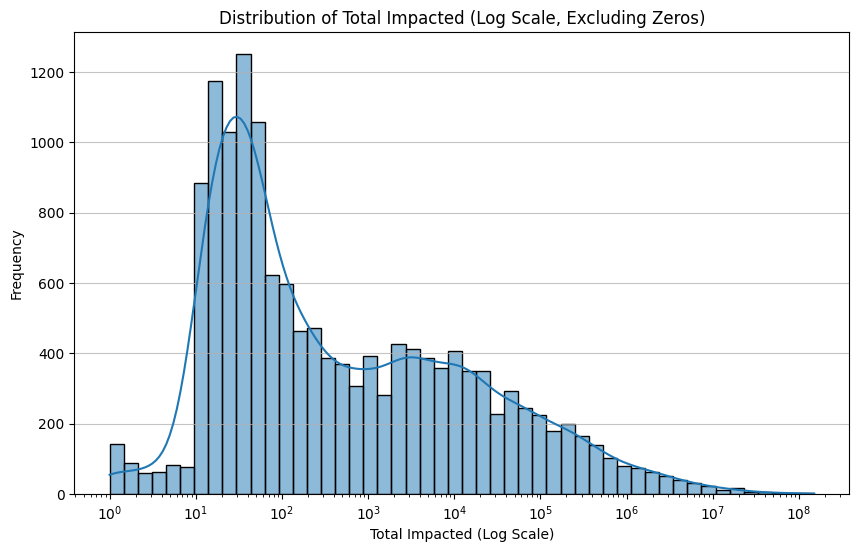

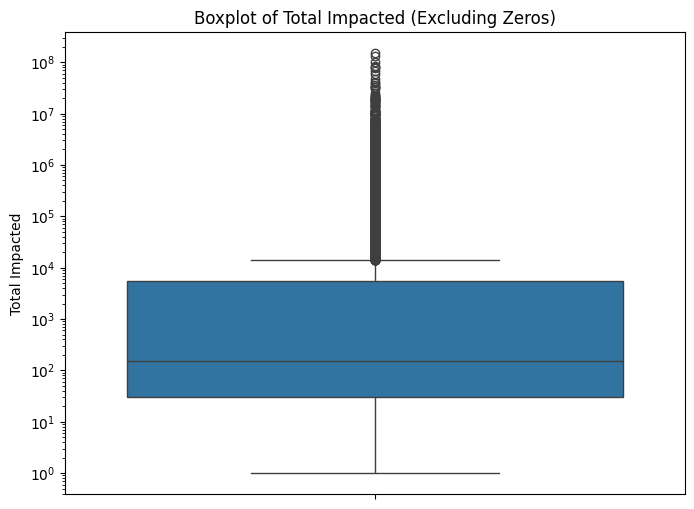

count    1.507300e+04
mean     1.930142e+05
std      2.607304e+06
min      0.000000e+00
25%      2.700000e+01
50%      1.350000e+02
75%      5.016000e+03
max      1.501464e+08
Name: Total Impacted, dtype: float64


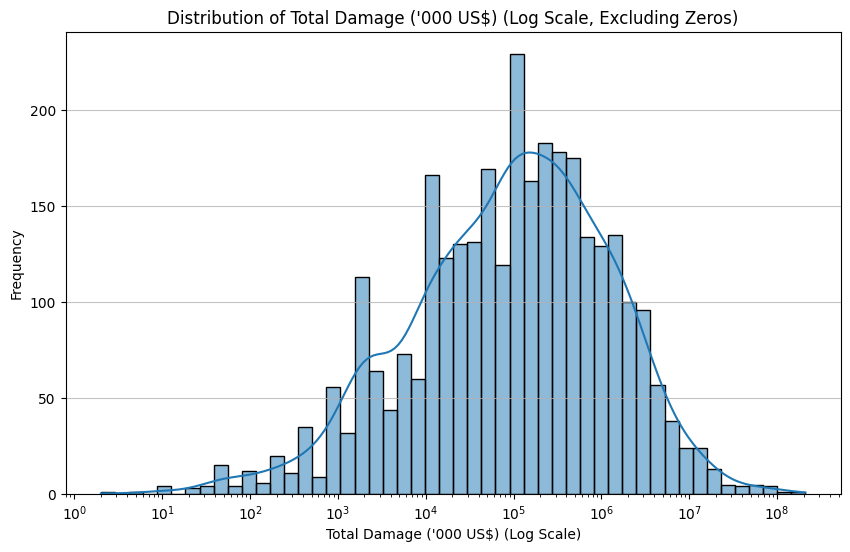

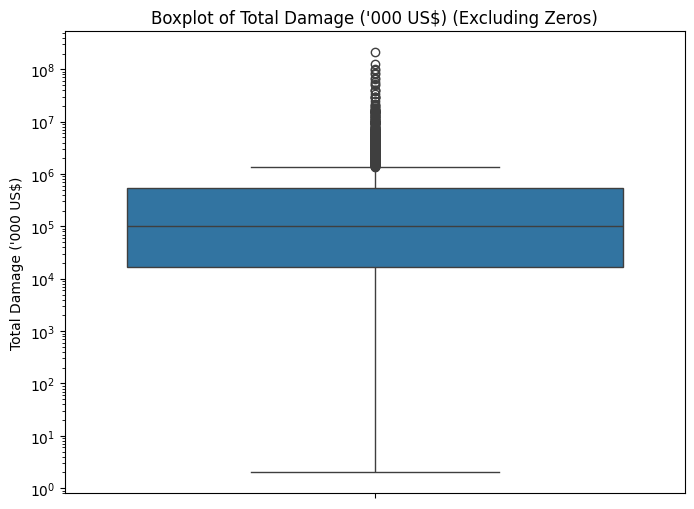

count    1.507300e+04
mean     2.459347e+05
std      2.979207e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.100000e+08
Name: Total Damage ('000 US$), dtype: float64


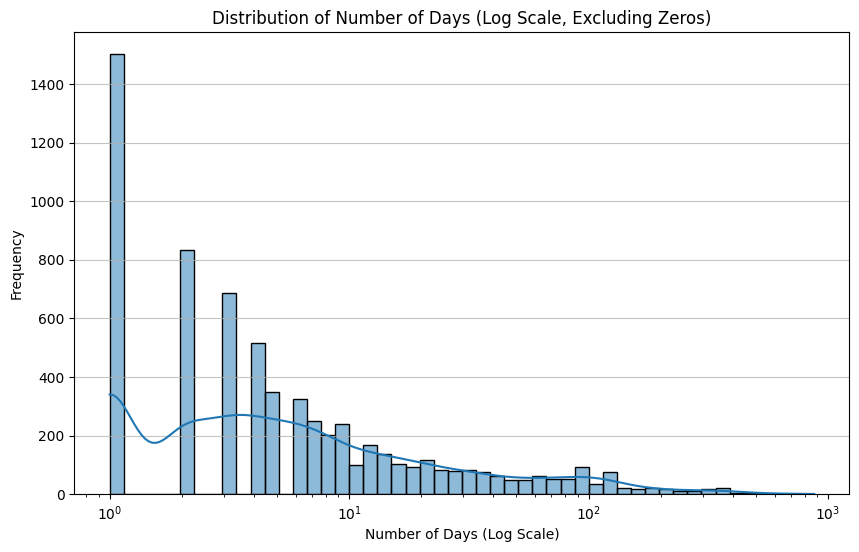

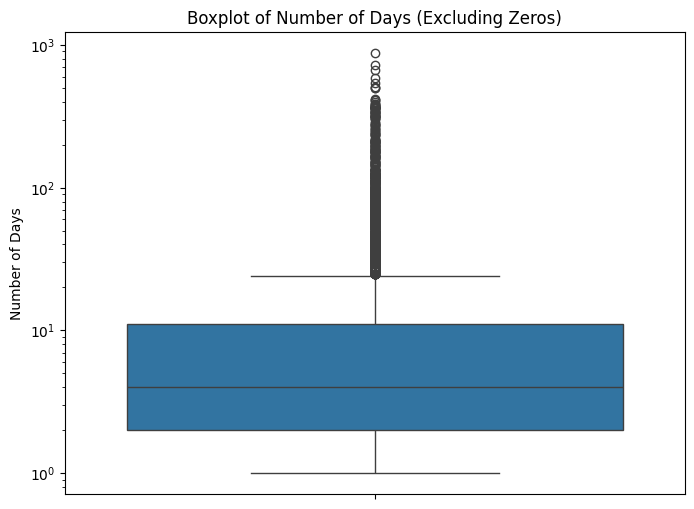

count    15073.000000
mean         7.656936
std         31.875091
min       -362.000000
25%          0.000000
50%          0.000000
75%          3.000000
max        876.000000
Name: Number of Days, dtype: float64


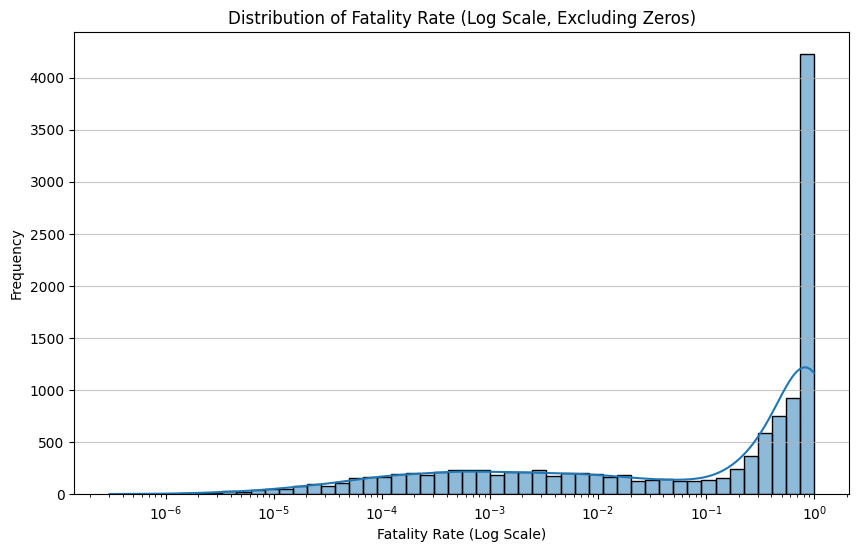

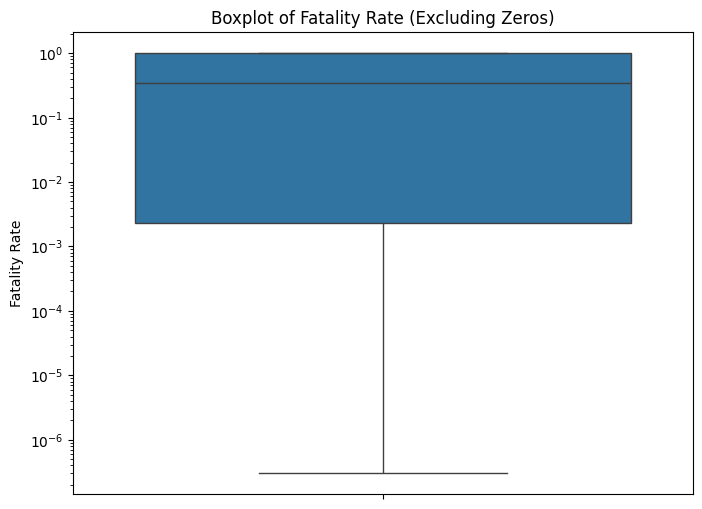

count    14693.000000
mean         0.373457
std          0.422639
min          0.000000
25%          0.000259
50%          0.099688
75%          0.884615
max          1.000000
Name: Fatality Rate, dtype: float64


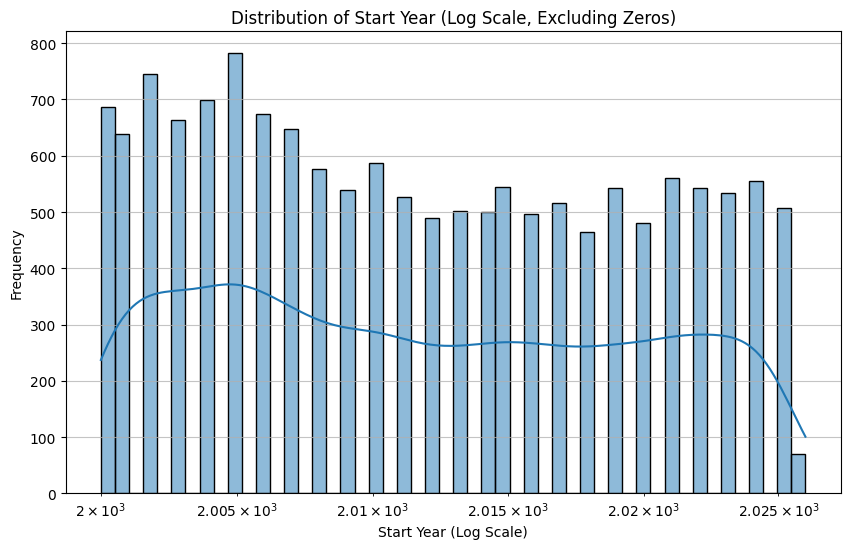

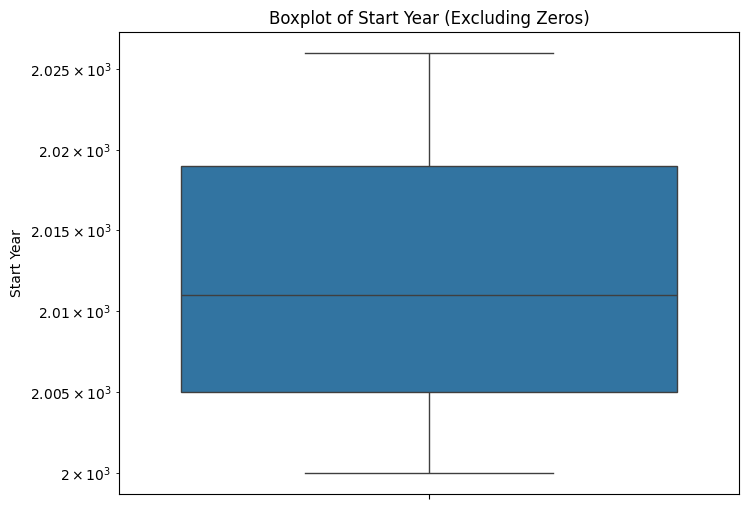

count    15073.000000
mean      2011.736748
std          7.683112
min       2000.000000
25%       2005.000000
50%       2011.000000
75%       2019.000000
max       2026.000000
Name: Start Year, dtype: float64


In [164]:
for col in most_important_cols:
    show_hist_distribution(col)
    show_boxplot_distribution(col)
    print(data[col].describe())

Total Impacted by Disaster Type

C:\Users\Mateus\AppData\Local\Temp\ipykernel_18824\2579940301.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=affected_by_type.values, y=affected_by_type.index, palette='viridis')


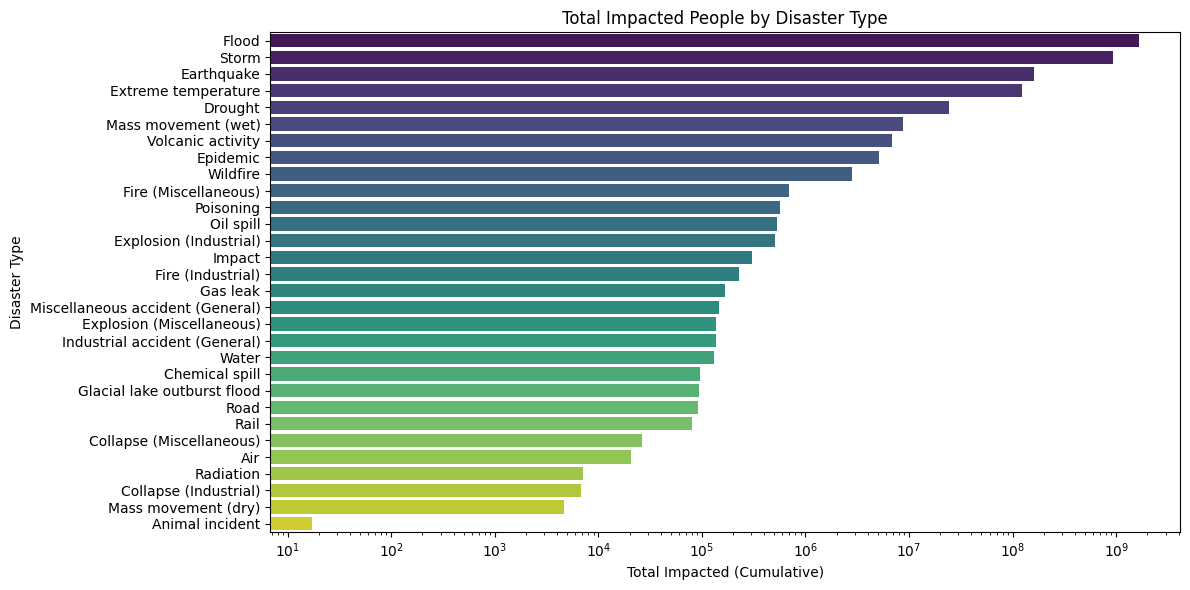

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Disaster Type and sum Total Impacted
affected_by_type = data.groupby('Disaster Type')['Total Impacted'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=affected_by_type.values, y=affected_by_type.index, palette='viridis')
plt.title('Total Impacted People by Disaster Type')
plt.xlabel('Total Impacted (Cumulative)')
plt.ylabel('Disaster Type')
plt.xscale('log')  # Log scale for better visibility
plt.tight_layout()
plt.show()

In [166]:
def show_correlation(data, x_col, y_col):
    correlation = data[x_col].corr(data[y_col])

    plt.figure(figsize=(10, 6))
    plt.scatter(data[x_col], data[y_col], alpha=0.5)
    plt.title(f'Relation Between {x_col} and {y_col}\n(Correlation: {correlation:.3f})')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True)
    plt.show()

    print(f"Correlation coefficient: {correlation:.4f}")

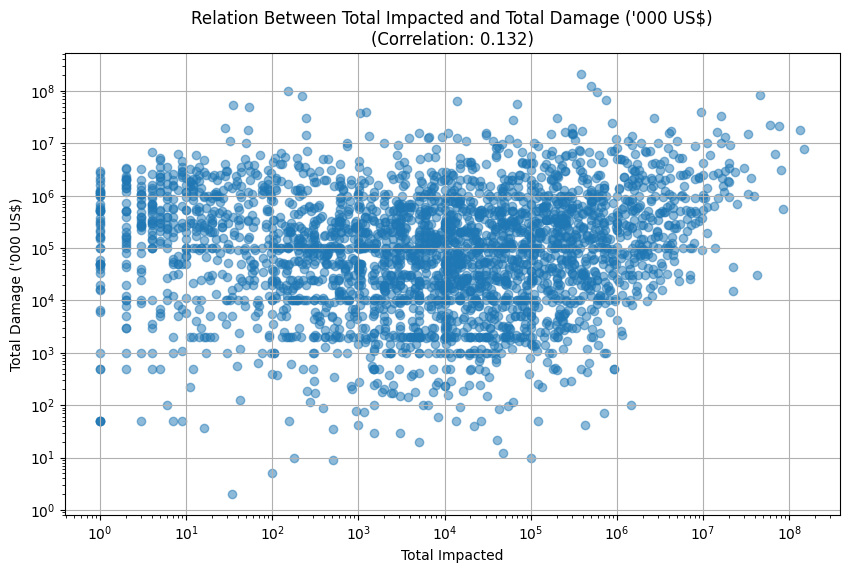

Correlation coefficient: 0.1319


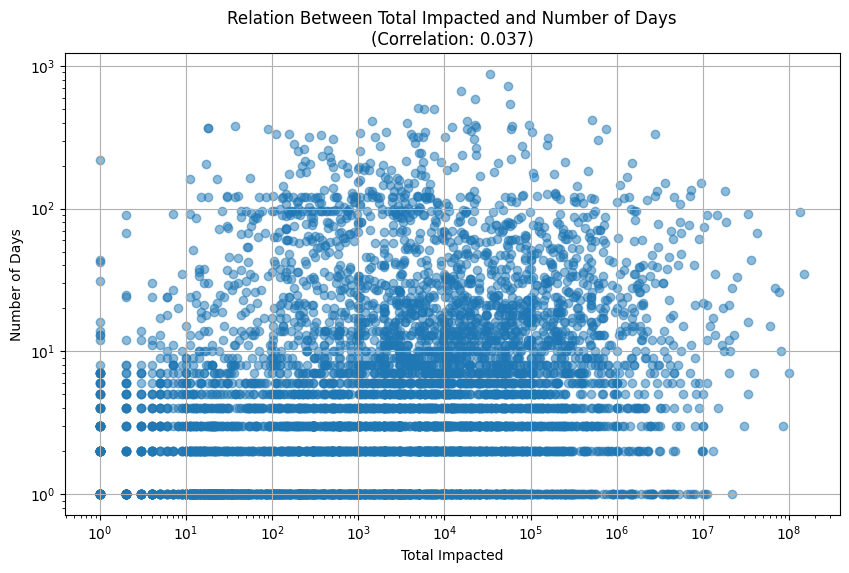

Correlation coefficient: 0.0371


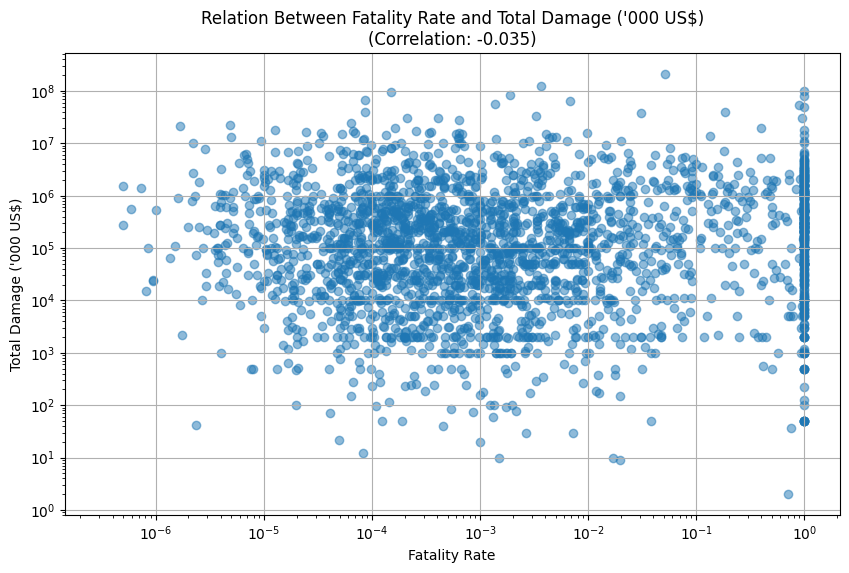

Correlation coefficient: -0.0346


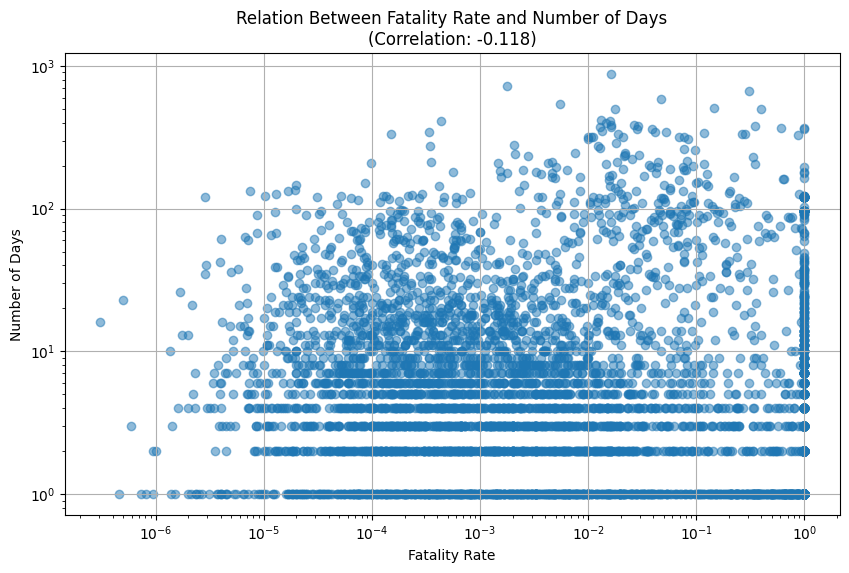

Correlation coefficient: -0.1176


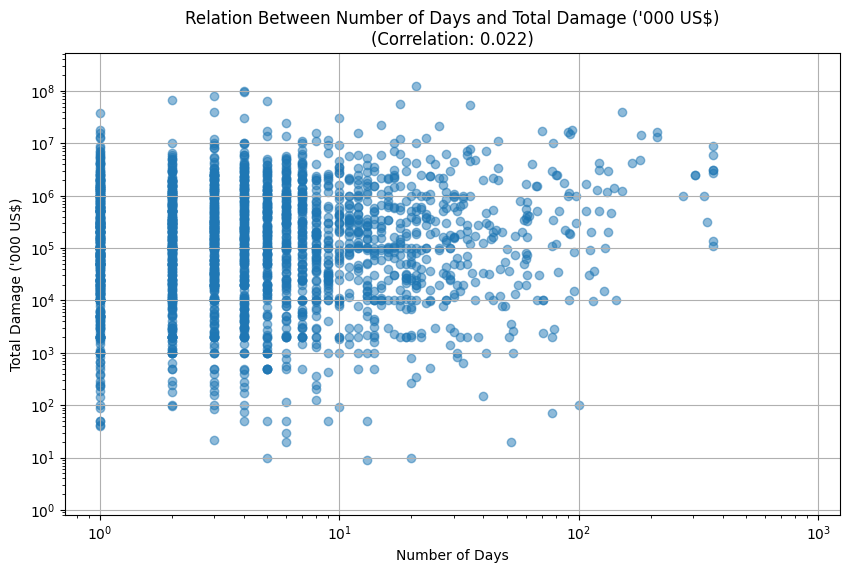

Correlation coefficient: 0.0219


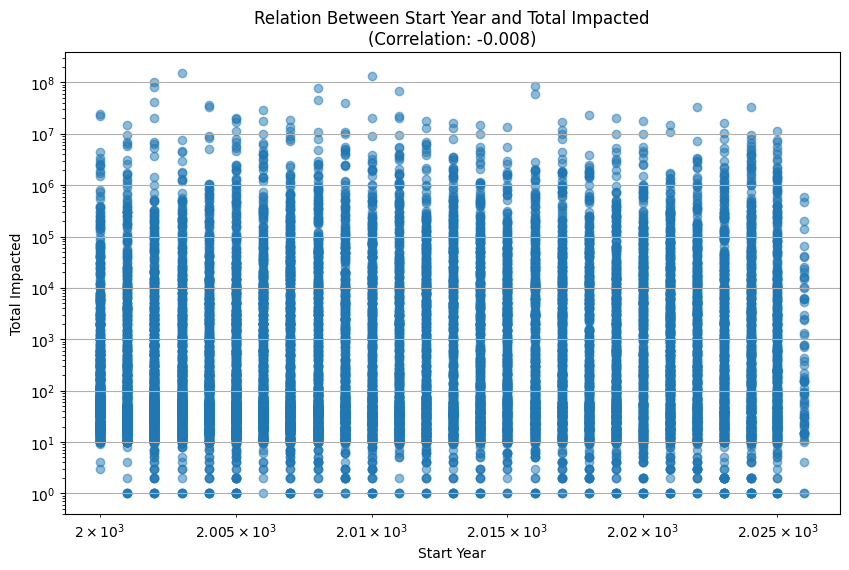

Correlation coefficient: -0.0082


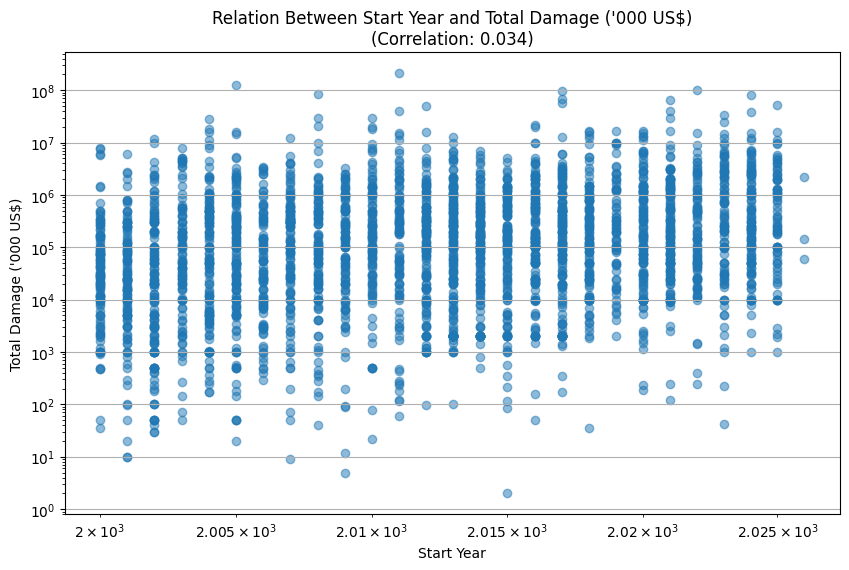

Correlation coefficient: 0.0341


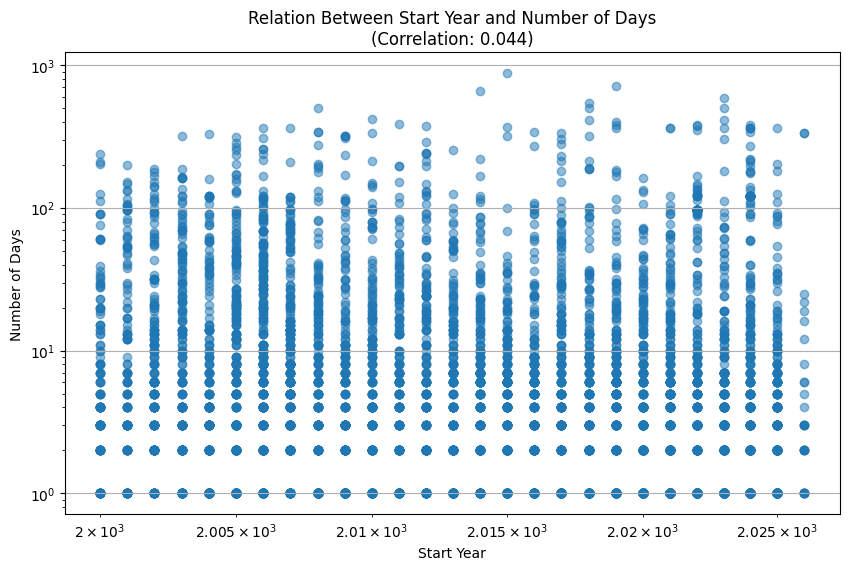

Correlation coefficient: 0.0435


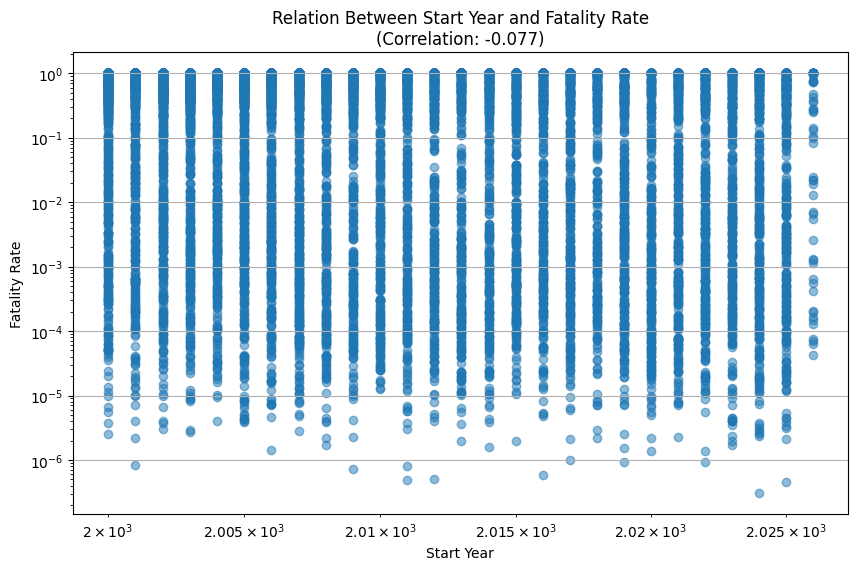

Correlation coefficient: -0.0765


In [186]:
show_correlation(data, 'Total Impacted', "Total Damage ('000 US$)")
show_correlation(data, 'Total Impacted', 'Number of Days')
show_correlation(data, 'Fatality Rate', "Total Damage ('000 US$)")
show_correlation(data, 'Fatality Rate', 'Number of Days')
show_correlation(data, 'Number of Days', "Total Damage ('000 US$)")
show_correlation(data, 'Start Year', 'Total Impacted')
show_correlation(data, 'Start Year', "Total Damage ('000 US$)")
show_correlation(data, 'Start Year', 'Number of Days')
show_correlation(data, 'Start Year', 'Fatality Rate')


Total Impacted by country

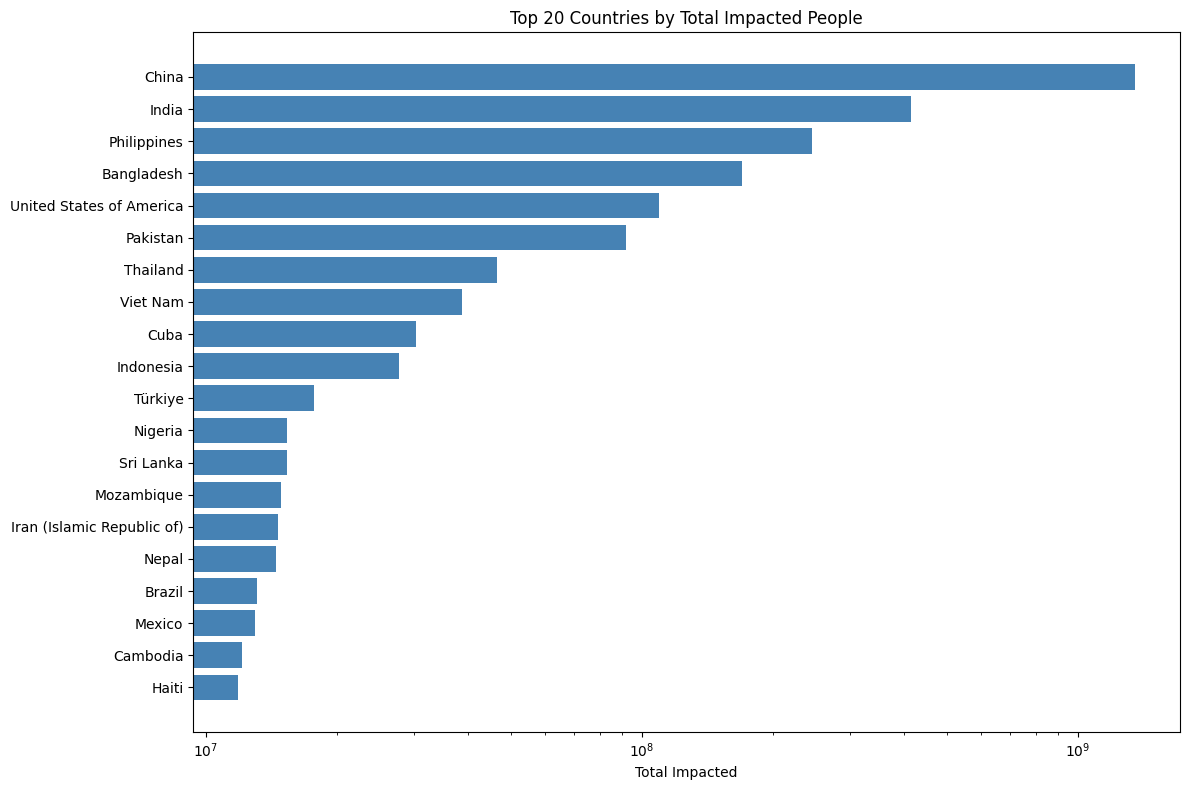

In [187]:
import matplotlib.pyplot as plt

# Group by Country and sum Total Impacted, sort in descending order
affected_by_country = data.groupby('Country')['Total Impacted'].sum().sort_values(ascending=True).tail(20)

plt.figure(figsize=(12, 8))
plt.barh(affected_by_country.index, affected_by_country.values, color='steelblue')
plt.title('Top 20 Countries by Total Impacted People')
plt.xlabel('Total Impacted')
plt.xscale('log')
plt.tight_layout()
plt.show()

Total Impacted by Disaster Type

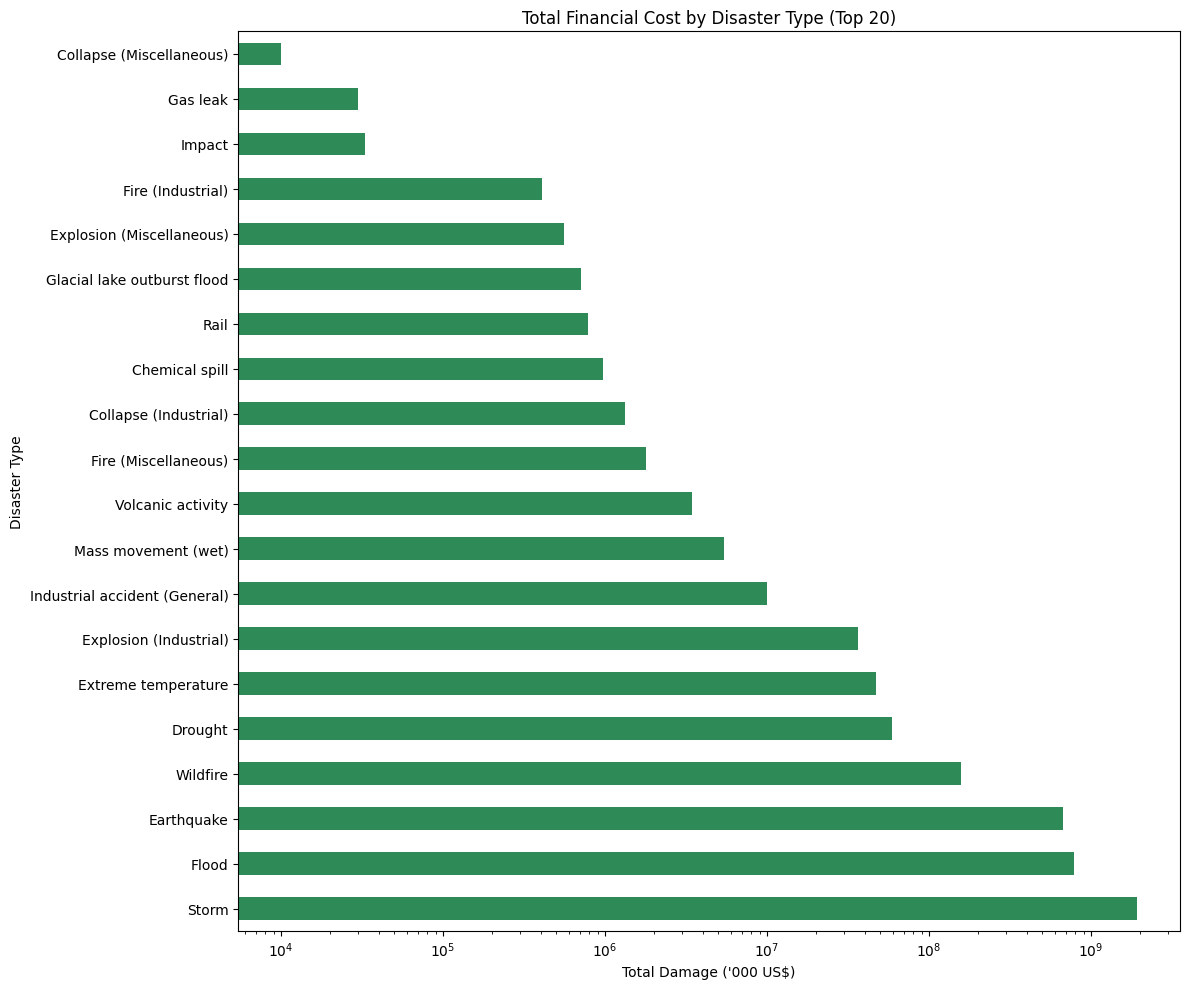

Top 20 disaster types by total damage:
Disaster Type
Storm                            1.927481e+09
Flood                            7.848037e+08
Earthquake                       6.677752e+08
Wildfire                         1.583628e+08
Drought                          5.900500e+07
Extreme temperature              4.740533e+07
Explosion (Industrial)           3.663940e+07
Industrial accident (General)    9.960407e+06
Mass movement (wet)              5.458231e+06
Volcanic activity                3.465433e+06
Fire (Miscellaneous)             1.785576e+06
Collapse (Industrial)            1.322000e+06
Chemical spill                   9.700000e+05
Rail                             7.830000e+05
Glacial lake outburst flood      7.100000e+05
Explosion (Miscellaneous)        5.560000e+05
Fire (Industrial)                4.100000e+05
Impact                           3.300000e+04
Gas leak                         3.000000e+04
Collapse (Miscellaneous)         1.000000e+04
Name: Total Damage ('000 US

In [188]:
import matplotlib.pyplot as plt

cost_by_type = (
    data[['Disaster Type', "Total Damage ('000 US$)"]]
    .dropna(subset=['Disaster Type', "Total Damage ('000 US$)"])
    .groupby('Disaster Type')["Total Damage ('000 US$)"].sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 10))
cost_by_type.head(20).plot(kind='barh', color='seagreen')
plt.title('Total Financial Cost by Disaster Type (Top 20)')
plt.xlabel("Total Damage ('000 US$)")
plt.ylabel('Disaster Type')
plt.xscale('log')
plt.tight_layout()
plt.show()

print('Top 20 disaster types by total damage:')
print(cost_by_type.head(20))

Getting correlation between disaster type and another metric

In [189]:
import matplotlib.pyplot as plt


def get_correlation_by_disaster_type(data, x_col, y_col, disaster_type):
    disasters = data[data['Disaster Type'] == disaster_type].copy()
    disasters = disasters[
        disasters[x_col].notna() &
        disasters[y_col].notna() &
        (disasters[x_col] > 0) &
        (disasters[y_col] > 0)
    ]

    disasters[x_col] = pd.to_numeric(disasters[x_col], errors='coerce')
    disasters[y_col] = pd.to_numeric(disasters[y_col], errors='coerce')
    disasters = disasters.dropna(subset=[x_col, y_col])

    return disasters[x_col].corr(disasters[y_col])


def show_corr_by_disaster_type(data, x_col, y_col, disaster_type):

    disasters = data[data['Disaster Type'] == disaster_type].copy()
    disasters = disasters[
        disasters[x_col].notna() &
        disasters[y_col].notna() &
        (disasters[x_col] > 0) &
        (disasters[y_col] > 0)
    ]

    disasters[x_col] = pd.to_numeric(disasters[x_col], errors='coerce')
    disasters[y_col] = pd.to_numeric(disasters[y_col], errors='coerce')
    disasters = disasters.dropna(subset=[x_col, y_col])

    disaster_corr = get_correlation_by_disaster_type(data, x_col, y_col, disaster_type)

    plt.figure(figsize=(10, 6))
    plt.scatter(disasters[x_col], disasters[y_col] , alpha=0.5)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'{disaster_type}: {x_col} vs {y_col}\n(Correlation: {disaster_corr:.3f})')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"{disaster_type} correlation coefficient: {disaster_corr:.4f}")


def get_disaster_types(df):
    return df['Disaster Type'].unique()

In [190]:
correlation_results = {}

for disaster_type in get_disaster_types(data):
    for i in range(len(most_important_cols)):
        for j in range(i + 1, len(most_important_cols)):
            filtered = data[
                (data['Disaster Type'] == disaster_type) &
                data[most_important_cols[i]].notna() &
                data[most_important_cols[j]].notna() &
                (data[most_important_cols[i]] > 0) &
                (data[most_important_cols[j]] > 0)
            ]
            correlation = filtered[most_important_cols[i]].corr(filtered[most_important_cols[j]])
            if filtered.shape[0] < 15 or abs(correlation) < 0.5:
                continue
            correlation_results[(most_important_cols[i], most_important_cols[j], disaster_type)] = correlation


for (x_col, y_col, disaster_type), corr in correlation_results.items():
    print(f"{disaster_type} - Correlation between {x_col} and {y_col}: {corr:.4f}")

c:\Users\Mateus\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Mateus\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Mateus\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Mateus\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Mateus\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Extreme temperature - Correlation between Total Impacted and Total Damage ('000 US$): 0.9555
Extreme temperature - Correlation between Number of Days and Start Year: 0.5897
Drought - Correlation between Number of Days and Start Year: 0.7119
